# TTD segment pricing — per-segment DiD, significance & effect size

A reusable, parameterized version of the per-segment analysis developed in
`TTD3_Pricing.ipynb` (per-segment DiD, pre-period-variance-based significance
test, Cohen's-d-style effect size, and how both evolve week-by-week as
post-period data accumulates). Instead of hard-coding a single bucket, this
notebook exposes `analyze_segments(full_paths=None, groups=None, bucket=None)`
so you can run the same analysis on **any list of segments, list of experiment
groups, or a whole bucket** and get back one row of results per segment.

Cells through the `did_b` construction are copied verbatim from
`TTD3_Pricing.ipynb` (same data load, zero-fill panel, bucket assignment, DiD
setup) — same scope, too: `did`/`test` is Global geo, sharethis only (the
provider/geo the pricing experiment actually applies to). Only the analysis
engine below that point is new.

**Method recap**: for each segment, `did` (already control-adjusted: the
segment's own pre→post change minus its matched control's average change) is
tested against zero using a t-test whose standard error comes from the
segment's own **pre-period** week-to-week variance (`sd_pre`) — not its
post-period variance, which can itself be shaped by the treatment. Effect size
is `did / sd_pre` (Cohen's-d-style, unitless) — how big the shift is relative
to this segment's normal noise, independent of how many post-period weeks have
accumulated. Both are also computed cumulatively, using only the first `k`
post-period weeks for `k = 1..n_post`, to show how the estimate and its
significance move as more data comes in.

In [1]:
import datetime
print(f"run @ {datetime.datetime.today().strftime('%Y%m%d-%H:%M:%S')}")

run @ 20260716-09:51:46


In [2]:
last_pre_week = "2026-05-24"
#test_df_start = "2026-05-01"
#test_df_start = "2026-04-10"
test_df_start = "2026-03-01"
base_PoM_default = {'dav2shreths':0.16, 'sharethis': 0.15}
# Bucket definition -- absolute revenue cutoffs (adjust as needed). Applied to
# `pricing['revenue']` right after it's loaded below, replacing the original
# rank-window bucket assignment.
#
# BUCKET_BOUNDARIES is a list of lower-bound revenue thresholds, any length,
# sorted descending. A segment's bucket is the largest boundary its revenue
# meets or exceeds (labeled by that boundary value); anything below the
# smallest boundary falls into '0', the catch-all (also its label). E.g. with
# [1000, 100, 10, 1]: revenue=250 -> '100' (>=100, <1000); revenue=0.4 -> '0'.
# Try a different number of buckets or different cutoffs by editing this one
# list -- BUCKET_ORDER, colors, subplot grids, and the ATE weighting all derive
# from it below (see the reassignment cell right after `pricing` is loaded).
BUCKET_BOUNDARIES = [1000, 100, 10, 1]


In [3]:
#adv_type = "Automotive"
adv_type = "All"

In [4]:
data_path = "/Users/ravirajan/code/data"
output_path = "/Users/ravirajan/code/outputs"
#ttd_file = f"{data_path}/TTD-20260608.csv"
#ttd_file = f"{data_path}/TTD-20260615.csv"
#ttd_file = f"{data_path}/TTD-20260623.csv"
ttd_file = f"{data_path}/TTD-20260714-AllOnly.csv"

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import matplotlib

In [7]:
import seaborn as sns

In [8]:
def get_split_means(dat1_sample, value = 'Avg_Relevance'):
    return dat1_sample.groupby(['week_start', 'Third_Party_Data_Provider_Id'])[[value]].mean().pivot_table(
    index='week_start', columns='Third_Party_Data_Provider_Id', values=value)

def get_split_plots(dat1_sample, x, y, kind='scatter', logx=False, logy=False):
    ax=None
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id == 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='branded taxonomy', color='green')
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id != 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='data alliance', color='orange')
    return ax

from matplotlib.pyplot import cm
def get_split_plots2(dat1_sample, x, y, kind='scatter', by='geo', logx=False, logy=False, alpha=1):
    ax=None
    vals = set(dat1_sample[by].values)
    color = cm.rainbow(np.linspace(0, 1, len(vals)))
    for i, val in enumerate(vals):
        ax=dat1_sample[dat1_sample[by] == val].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label=val, color=color[i], alpha=alpha)
    return ax

In [9]:
dat0 = pd.read_csv(ttd_file, low_memory=False).replace(' ', None)
pricing = pd.read_csv(f"{data_path}/Price_Expt_Assignments2.csv")

In [10]:
# ─── Load Ranked_by_Revenue early — bucket assignment (below) needs it ────────
# Loaded here (rather than only in the later "Full revenue pool" cell) so bucket
# assignment can join against it directly instead of trusting pricing['revenue']
# to already match -- see the bucket-reassignment cell right after this one.
ttd_path = '/Users/ravirajan/Projects/TTD'
in_p = f"{ttd_path}/Ranked_by_Revenue.csv"
rev_pool = pd.read_csv(in_p)


In [11]:
# ─── Assign bucket on Ranked_by_Revenue, then join onto pricing ──────────────
# Bucket is computed on the fly for every segment in `rev_pool` (the full
# Ranked_by_Revenue universe) -- not just pricing's ~2000 experiment candidates
# -- using directly-tunable revenue thresholds (BUCKET_BOUNDARIES at the top of
# the notebook). It's then joined onto `pricing` by (Full_Path, Provider).
# Computing it on the universe first (rather than only on pricing's own
# `revenue` column) means the same bucket definition is available for the full
# population too -- used below to weight the ATE by the true population's
# bucket composition, not just the experiment's candidate pool.
#
# Every downstream use of `bucket` (did_b, outlier tables, ATE bucket weights,
# did_vol) reads from pricing['bucket'], so this one join propagates everywhere
# without needing to touch each site individually.
#
# IMPORTANT -- time scale: `rev_pool` (Ranked_by_Revenue.csv) is a MONTHLY
# revenue figure (see the "Full revenue pool" cell below). BUCKET_BOUNDARIES
# are therefore monthly thresholds -- a different time scale from everything
# else in the DiD/ATE analysis (`dat`/`dat1_filled`/`did`/`total_panel_weekly_rev`,
# all WEEKLY Data_Cost). A segment labeled '100+' clears $100/month, not
# $100/week -- don't compare a bucket label directly against a weekly $ figure.

# Sort descending regardless of input order, and de-dup -- np.select's
# first-match-wins semantics require descending order to pick the largest
# boundary a segment clears; a duplicate would make one of the two labels
# unreachable.
_boundaries = sorted(set(BUCKET_BOUNDARIES), reverse=True)
assert len(_boundaries) == len(BUCKET_BOUNDARIES), \
    "BUCKET_BOUNDARIES has duplicate values -- each boundary must be unique"
assert len(_boundaries) >= 1, "BUCKET_BOUNDARIES must have at least one value"

def _fmt(x):
    """Label for a boundary value -- '1000+' not '1000.0', '0.05+' not '0.05000'."""
    return f"{x:g}+"

_labels = [_fmt(b) for b in _boundaries]          # descending, matches _boundaries
ZERO_BUCKET_LABEL = '0+'                           # catch-all below the smallest boundary

# BUCKET_ORDER: ascending (lowest revenue -> highest), for consistency with how
# every downstream plot/table already expects to iterate buckets low-to-high.
BUCKET_ORDER = [ZERO_BUCKET_LABEL] + list(reversed(_labels))

# ── bucket on the full universe (rev_pool) ────────────────────────────────────
_rev_pool_revenue = rev_pool['revenue'].fillna(0.0)
rev_pool['bucket'] = np.select(
    [_rev_pool_revenue >= b for b in _boundaries],
    _labels,
    default=ZERO_BUCKET_LABEL
)

# ── join that bucket assignment onto pricing (the experiment/candidate table) ─
# pricing is itself built as a subset of Ranked_by_Revenue (see
# TTD_Pricing_Simple_Experiment.ipynb), so every (Full_Path, Provider) key in
# pricing is expected to exist in rev_pool -- verified below, this is a key
# match, not a revenue-value match. Separately, rev_pool's own `revenue` column
# is null for some of those matched rows (the segment exists in the file, but
# with no reported revenue) -- already handled by the .fillna(0.0) above before
# bucketing, so it shows up as '0+', not as a join failure.
_bucket_by_seg = rev_pool.drop_duplicates(['Full_Path', 'Third_Party_Data_Provider_Id']) \
    .set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])['bucket']
pricing['bucket'] = (
    pricing.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).index.map(_bucket_by_seg)
)
_n_key_unmatched = pricing['bucket'].isna().sum()
pricing['bucket'] = pricing['bucket'].fillna(ZERO_BUCKET_LABEL)
_n_null_revenue = pricing.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).index.map(
    rev_pool.drop_duplicates(['Full_Path', 'Third_Party_Data_Provider_Id'])
    .set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])['revenue']
).isna().sum()
print(f"Bucketing: {len(pricing) - _n_key_unmatched:,} of {len(pricing):,} pricing segments found by key "
      f"in Ranked_by_Revenue.csv ({_n_key_unmatched:,} key not found, treated as {ZERO_BUCKET_LABEL} / $0 monthly)")
print(f"  of those found, {_n_null_revenue:,} have a null revenue value in Ranked_by_Revenue itself "
      f"(segment exists, revenue unreported) -- also treated as $0 monthly, so still '{ZERO_BUCKET_LABEL}'")

# ── Ensure every experiment group stays within a single bucket ────────────────
# `bucket` is a per-segment (revenue-based) label, but `group` pairs segments
# together for control-matching in the DiD (each group has n members, one per
# delta -- typically 3 for -/0/+, sometimes 6 for two of each). If a group's
# revenue straddles a boundary, its members can land in different buckets --
# silently mixing revenue tiers into the same control-matched comparison (a
# treated segment's own control partner could end up counted in a different
# bucket's analysis). Rather than drop these edge cases, move the WHOLE group
# to a single bucket via majority vote among its members.
#
# IMPORTANT: `group` numbers restart at 0 independently per provider (e.g.
# dav2shreths group 2 and sharethis group 2 are unrelated experimental units
# that happen to share an integer id) -- grouping by `group` alone would
# silently merge two different providers' groups into one check. Group by
# (Provider, group) instead.
#
# Ties (e.g. a 6-member group split evenly 3-3) are broken by the bucket of the
# group's median-revenue member -- deterministic, no data dropped either way.
# In practice, grouping correctly by provider leaves no genuine ties: the only
# spanning groups that remain are clean majorities (3-member groups can only
# split 2-1), verified below via _n_ties. The tiebreak code is kept regardless,
# in case a future BUCKET_BOUNDARIES choice or larger group size produces one.
_group_bucket_counts = pricing.groupby(['Third_Party_Data_Provider_Id', 'group'])['bucket'].nunique()
_spanning_groups = _group_bucket_counts[_group_bucket_counts > 1].index  # MultiIndex of (provider, group)
print(f"\nGroups spanning more than one bucket: {len(_spanning_groups)} of {len(_group_bucket_counts)}")

if len(_spanning_groups) > 0:
    _bucket_by_seg_rev = rev_pool.drop_duplicates(['Full_Path', 'Third_Party_Data_Provider_Id']) \
        .set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])['revenue']
    pricing['_bucketing_revenue'] = pricing.set_index(
        ['Full_Path', 'Third_Party_Data_Provider_Id']).index.map(_bucket_by_seg_rev)
    pricing['_bucketing_revenue'] = pricing['_bucketing_revenue'].fillna(0.0)

    _n_reassigned, _n_ties = 0, 0
    for prov, g in _spanning_groups:
        mask = (pricing['Third_Party_Data_Provider_Id'] == prov) & (pricing['group'] == g)
        sub = pricing.loc[mask]
        counts = sub['bucket'].value_counts()
        top = counts[counts == counts.max()].index.tolist()
        if len(top) == 1:
            winner = top[0]
        else:
            _n_ties += 1
            median_rev = sub['_bucketing_revenue'].median()
            winner = sub.loc[(sub['_bucketing_revenue'] - median_rev).abs().idxmin(), 'bucket']
        _n_reassigned += int((sub['bucket'] != winner).sum())
        pricing.loc[mask, 'bucket'] = winner

    pricing.drop(columns=['_bucketing_revenue'], inplace=True)
    print(f"  reassigned {_n_reassigned} segments to their group's majority bucket ({_n_ties} groups needed tie-break)")

assert (pricing.groupby(['Third_Party_Data_Provider_Id', 'group'])['bucket'].nunique() <= 1).all(), \
    "a (provider, group) still spans multiple buckets after majority-rule correction"

# Shared color map, keyed by bucket name, used everywhere a per-bucket color is
# needed (bar/violin/scatter plots) so it automatically covers however many
# tiers BUCKET_BOUNDARIES currently implies.
BUCKET_COLORS = dict(zip(BUCKET_ORDER, plt.cm.RdYlGn_r(np.linspace(0.05, 0.95, len(BUCKET_ORDER)))))

# Verify: every rev_pool row landed in exactly one bucket (no overlap, no gap),
# and each bucket's members actually satisfy that bucket's own revenue range.
assert rev_pool['bucket'].isin(BUCKET_ORDER).all(), "found a bucket label outside BUCKET_ORDER"
assert rev_pool['bucket'].notna().all(), "found an unassigned (NaN) bucket"
for i, label in enumerate(_labels):
    lo = _boundaries[i]
    hi = _boundaries[i - 1] if i > 0 else None   # None -> no upper bound (top bucket)
    in_bucket = _rev_pool_revenue[rev_pool['bucket'] == label]
    assert (in_bucket >= lo).all(), f"a '{label}' row is below its own lower bound ({lo})"
    if hi is not None:
        assert (in_bucket < hi).all(), f"a '{label}' row reaches the next boundary up ({hi}), should be '{_fmt(hi)}'"
below_smallest = _rev_pool_revenue[rev_pool['bucket'] == ZERO_BUCKET_LABEL]
assert (below_smallest < _boundaries[-1]).all(), f"a '{ZERO_BUCKET_LABEL}' row clears the smallest boundary ({_boundaries[-1]})"
assert pricing['bucket'].isin(BUCKET_ORDER).all(), "pricing bucket join produced a label outside BUCKET_ORDER"

print(f"Bucket assigned from monthly-revenue boundaries {_boundaries} (labels: {BUCKET_ORDER}):")
print("rev_pool (full universe):")
print(rev_pool.groupby(['Third_Party_Data_Provider_Id', 'bucket']).size().unstack(fill_value=0).reindex(columns=BUCKET_ORDER))
print("pricing (experiment candidates, joined from rev_pool):")
print(pricing.groupby(['Third_Party_Data_Provider_Id', 'bucket']).size().unstack(fill_value=0).reindex(columns=BUCKET_ORDER))


Bucketing: 2,037 of 2,037 pricing segments found by key in Ranked_by_Revenue.csv (0 key not found, treated as 0+ / $0 monthly)
  of those found, 567 have a null revenue value in Ranked_by_Revenue itself (segment exists, revenue unreported) -- also treated as $0 monthly, so still '0+'

Groups spanning more than one bucket: 2 of 679
  reassigned 2 segments to their group's majority bucket (0 groups needed tie-break)
Bucket assigned from monthly-revenue boundaries [1000, 100, 10, 1] (labels: ['0+', '1+', '10+', '100+', '1000+']):
rev_pool (full universe):
bucket                          0+   1+  10+  100+  1000+
Third_Party_Data_Provider_Id                             
dav2shreths                   1706  251  147    37      5
sharethis                     2364  535  442   207     32
pricing (experiment candidates, joined from rev_pool):
bucket                         0+   1+  10+  100+  1000+
Third_Party_Data_Provider_Id                            
dav2shreths                   720  171  

In [12]:
dat0['Week_Start_Date'].max()

'2026-06-29 00:00:00+00'

In [13]:
dat0.head(3)

,Active_ID_Count,Active_ID_Count_Percentile,Advertiser_Category,Avg_Relevance,Avg_Relevance_Percentile,Avg_Value_Percentile,Avg_Value_Score,Data_Cost,Effective_Impression_Count,Full_Path,...,Match_Pct_Percentile,Paid_Pct,Paid_Pct_Percentile,Received_ID_Count,Selected_Pct,Selected_Pct_Percentile,Third_Party_Data_Provider_Element_Id,Third_Party_Data_Provider_Id,Third_Party_Data_Sub_Provider_Id,Week_Start_Date
0,204688200.0,97.3,All,4.2,79.5,94.0,58.0,0.09,8612.0,Data Alliance > Education > Interest > Global ...,...,88.3,23.7,80.2,465473100.0,0.0024,83.1,NaN,dav2shreths,None,2026-01-05 00:00:00+00
1,NaN,NaN,All,4.3,80.2,NaN,NaN,NaN,NaN,Data Alliance > Pets & Animals > Interest > Gl...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
2,183006000.0,97.1,All,4.3,81.0,94.0,58.0,31.09,232037.0,Data Alliance > Shopping > Interest > Global >...,...,96.6,88.8,93.2,418018700.0,0.0133,95.5,NaN,dav2shreths,None,2026-01-05 00:00:00+00


In [14]:
pricing.head(3)    

,Unnamed: 0.1,Unnamed: 0,Third_Party_Data_Provider_Id,group,Full_Path,revenue,rev_rank,geo,assignment,incr,bucket
0,0,0.0,dav2shreths,0,Data Alliance > Business & Finance > Interest ...,2421.51,1,Global,1,0.05,1000+
1,1,2.0,dav2shreths,0,Data Alliance > Demographic > Interest > Globa...,1983.75,2,Global,-1,0.05,1000+
2,2,1.0,dav2shreths,0,Data Alliance > Business & Finance > Interest ...,1336.34,3,Global,0,0.05,1000+


In [15]:
dat = pd.DataFrame(dat0, copy=True) # prices changed 5-26 so capturing weeks from 5-18
dat['post'] = dat['Week_Start_Date'].apply(lambda x: 1 if x > last_pre_week else 0)

In [16]:
def add_prices(dat, base_PoM_default, pricing):
    dat = dat.set_index('Third_Party_Data_Provider_Id').join(pd.DataFrame([base_PoM_default]).T[[0]]).reset_index()
    cols = list(dat.columns)
    cols[-1] = 'base_PoM'
    dat.columns = cols
    #
    pricing['delta'] = pricing['assignment'] * pricing['incr']
    dat = dat.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).join(
        pricing.set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])[['group', 'delta', 'bucket']], how='left').reset_index()
    dat['delta'] = dat['delta'].fillna(0)
    dat['price'] = dat['base_PoM'] + dat['delta'] * dat['post']  # delta only applies post-treatment
    return dat


In [17]:
dat = add_prices(dat, base_PoM_default, pricing)

In [18]:
def get_geo(litems):
    check = ['Asia', 'US', 'Global', 'APAC']
    for c in check:
        if c in litems:
            return c
    return 'Unknown'

In [19]:
dat['geo'] = dat.Full_Path.apply(lambda x: get_geo(x.replace(" ", "").split(">")))

In [20]:
dat.groupby('geo')[['Data_Cost']].sum() / dat['Data_Cost'].sum()

,Data_Cost
geo,
APAC,0.014209
Asia,0.013768
Global,0.472449
US,0.330870
Unknown,0.168704


In [21]:
dat.groupby('geo')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
geo,,,,,,,,
APAC,312.0,0.150000,8.340049e-16,0.15,0.15,0.15,0.15,0.15
Asia,31720.0,0.150016,4.045625e-04,0.15,0.15,0.15,0.15,0.16
Global,82238.0,0.156775,1.641791e-02,0.10,0.15,0.16,0.16,0.21
US,21606.0,0.150000,5.715005e-14,0.15,0.15,0.15,0.15,0.15
Unknown,13349.0,0.150019,4.409154e-04,0.15,0.15,0.15,0.15,0.16


In [22]:
dat.groupby('geo')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
geo,,,,,,,,
APAC,312.0,0.150000,8.340049e-16,0.15,0.15,0.15,0.15,0.15
Asia,31720.0,0.150016,4.045625e-04,0.15,0.15,0.15,0.15,0.16
Global,82238.0,0.156775,1.641791e-02,0.10,0.15,0.16,0.16,0.21
US,21606.0,0.150000,5.715005e-14,0.15,0.15,0.15,0.15,0.15
Unknown,13349.0,0.150019,4.409154e-04,0.15,0.15,0.15,0.15,0.16


In [23]:
dat['Clean_Path'] = dat.Full_Path.apply(lambda x: x.lower().replace(" ", ""))
dat['segment_last'] = dat.Clean_Path.apply(lambda x: x.split(">")[-1].replace("age", ""))
dat['segment_1'] = dat.Clean_Path.apply(lambda x: x.split(">")[0])
##dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.replace("otp>", "").split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['week_start'] = dat.Week_Start_Date.apply(lambda x: x.split(" ")[0])

In [24]:
len(dat['segment_last'].unique()), len(dat['segment_1'].unique()), len(dat['segment_2'].unique())

(3208, 19, 82)

# EDA

In [25]:
# ─── Zero-filled segment x week panel — universal list from `pricing` ────────
# `dat` only contains rows TTD actually reported; if a segment had zero matched
# IDs in a week, the row is absent entirely (not NaN) -- Received_ID_Count.notna()
# can't recover that, and downstream joins (pre/post pivot, control group match)
# silently drop segments/groups whose data happens to be sparse, hitting low
# revenue segments hardest (see funnel investigation above `add_prices`). Build
# the full (segment x week) grid from pricing's own experiment assignment
# (already carries group/delta/bucket, independent of what TTD reported) and
# fill missing weeks with zero revenue / zero impressions.
universe = pricing[['Full_Path', 'Third_Party_Data_Provider_Id', 'group', 'bucket']].drop_duplicates()
universe = universe.merge(
    pricing[['Full_Path', 'Third_Party_Data_Provider_Id', 'delta']].drop_duplicates(),
    on=['Full_Path', 'Third_Party_Data_Provider_Id']
)
universe['geo'] = universe['Full_Path'].apply(lambda x: get_geo(x.replace(" ", "").split(">")))

_all_weeks = pd.DataFrame({'Week_Start_Date': dat['Week_Start_Date'].unique()})
_grid = universe.merge(_all_weeks, how='cross')


_adv_rows = dat
dat1_filled = _grid.merge(
    _adv_rows,
    # delta/bucket included here too (like geo/group) -- both `_grid` (via
    # universe/pricing) and `dat` (via add_prices' own pricing join) carry
    # them; without listing them as join keys pandas silently suffixes both
    # to delta_x/delta_y, bucket_x/bucket_y instead of erroring, which broke
    # every downstream reference to a plain `delta`/`bucket` column.
    on=['Full_Path', 'Third_Party_Data_Provider_Id', 'Week_Start_Date', 'geo', 'group', 'delta', 'bucket'],
    how='left'
)

n_missing = dat1_filled['Data_Cost'].isna().sum()
dat1_filled['Data_Cost'] = dat1_filled['Data_Cost'].fillna(0.0)
dat1_filled['Effective_Impression_Count'] = dat1_filled['Effective_Impression_Count'].fillna(0.0)
dat1_filled['post'] = dat1_filled['Week_Start_Date'].apply(lambda x: 1 if x > last_pre_week else 0)

print(f"dat1_filled: {len(dat1_filled):,} rows across {universe['Full_Path'].nunique():,} segments "
      f"x {len(_all_weeks)} weeks")
print(f"  {n_missing:,} rows ({n_missing/len(dat1_filled)*100:.1f}%) had no matching row in the raw "
      f"export -- filled with zero")


dat1_filled: 52,962 rows across 2,037 segments x 26 weeks
  20,276 rows (38.3%) had no matching row in the raw export -- filled with zero


In [26]:
dat1_filled.head().T

,0,1,2,3,4
Full_Path,Data Alliance > Business & Finance > Interest ...,Data Alliance > Business & Finance > Interest ...,Data Alliance > Business & Finance > Interest ...,Data Alliance > Business & Finance > Interest ...,Data Alliance > Business & Finance > Interest ...
Third_Party_Data_Provider_Id,dav2shreths,dav2shreths,dav2shreths,dav2shreths,dav2shreths
group,0,0,0,0,0
bucket,1000+,1000+,1000+,1000+,1000+
delta,0.05,0.05,0.05,0.05,0.05
geo,Global,Global,Global,Global,Global
Week_Start_Date,2026-01-05 00:00:00+00,2026-01-12 00:00:00+00,2026-01-19 00:00:00+00,2026-01-26 00:00:00+00,2026-02-02 00:00:00+00
Active_ID_Count,172399000.0,166032500.0,156332900.0,159633300.0,167280100.0
Active_ID_Count_Percentile,96.9,96.7,96.7,96.7,96.7
Advertiser_Category,All,All,All,All,All


In [27]:
# dat1_filled carries all 15 Advertiser_Category rows per segment/week (14
# category breakdowns + the 'All' rollup) -- filter down to 'All' here, not in
# dat1_filled's own construction, so dat1_filled itself stays usable as the
# full panel (e.g. for anything that legitimately wants category breakdowns).
#
# Deliberately NOT filtering on Received_ID_Count.isna() here (unlike the old
# dat1): that would drop exactly the zero-filled rows (segments/weeks with no
# original data, Received_ID_Count left NaN by the left-join) that the whole
# zero-fill exercise exists to keep -- `test` in the DiD section is built from
# this dat1, so those rows need to survive. The RF/regression model further
# down filters to Received_ID_Count > 0 on its own (see dat2), which already
# excludes these NaN/zero rows for that purpose without dat1 needing to.
dat1 = dat1_filled[dat1_filled.Advertiser_Category == adv_type].copy()
dat1['Received_ID_Count'] = dat1['Received_ID_Count'].fillna(0)
dat1['Active_ID_Count'] = dat1['Active_ID_Count'].fillna(0)
dat1.shape

(52962, 33)

In [28]:
dat1['Received_ID_Count'] = dat1['Received_ID_Count'].astype(int)
dat1['Active_ID_Count'] = dat1['Active_ID_Count'].astype(int)
dat1['Effective_Impression_Count'] = dat1['Effective_Impression_Count'].astype(int)

In [29]:
dat['Data_Cost'] = dat['Data_Cost'].astype(float)
dat1['Match_Pct'] = dat1['Match_Pct'].astype(float)
dat1['Match_Pct_Percentile'] = dat1['Match_Pct_Percentile'].astype(float)

## DiD setup — build `did` (verbatim from TTD3_Pricing.ipynb)

In [30]:
# Built from dat1 (Advertiser_Category=='All' only -- dat1_filled itself
# still has all 15 category rows per segment/week; see dat1's definition).
test = dat1[~dat1.group.isna()]
test = test[test.Week_Start_Date > test_df_start]
test = test[test.Third_Party_Data_Provider_Id == 'sharethis']
test_means = test.groupby(['group', 'Full_Path', 'delta', 'post'])[['Data_Cost']].mean()


In [31]:
test_means_joined = test_means.xs(0, level='post').join(
    test_means.xs(1, level='post'), lsuffix='_pre', rsuffix='_post'
).reset_index()
test_means_joined['chg'] = test_means_joined['Data_Cost_post'] - test_means_joined['Data_Cost_pre']
test_means_joined['chg_ratio'] = test_means_joined['chg'] / test_means_joined['Data_Cost_pre']

In [32]:
import numpy as np
from scipy import stats
from scipy.stats import trim_mean as __trim_mean

# --- compute DiD ---
control_mean_by_group = (
    test_means_joined[test_means_joined['delta'] == 0]
    .groupby('group')['chg']
    .mean()
    .rename('control_chg_mean')
)
did = (
    test_means_joined
    .join(control_mean_by_group, on='group')
    .dropna(subset=['control_chg_mean'])
    .copy()
)
did['did'] = did['chg'] - did['control_chg_mean']
control_level_by_group = (
    test_means_joined[test_means_joined['delta'] == 0]
    .groupby('group')['Data_Cost_pre']
    .mean()
    .rename('control_level')
)
did = did.join(control_level_by_group, on='group')
did_col   = 'did'
did_label = 'DiD  (post-pre vs control)'

# --- shared functions ---
def ttest_trimmed(vals, trim=0.1):
    a = np.sort(vals)
    k = int(np.floor(trim * len(a)))
    return stats.ttest_1samp(a[k: len(a) - k], popmean=0)

def wilcoxon_safe(vals):
    try:
        _, p = stats.wilcoxon(vals)
        return p
    except ValueError:
        return 1.0  # all values zero — no evidence against null

def p_label(p):
    if p < 0.001: return 'p<0.001'
    if p < 0.05:  return f'p={p:.3f}'
    return f'p={p:.3f} (n.s.)'

def desc_stats(did, col):
    rows = []
    for d in sorted(did['delta'].unique()):
        vals = did[did['delta'] == d][col].dropna().values
        _, p_t     = stats.ttest_1samp(vals, popmean=0)
        _, p_trim  = ttest_trimmed(vals)
        p_wilcox   = wilcoxon_safe(vals)
        q = lambda pct: round(float(np.quantile(vals, pct)), 3)
        rows.append({
            'delta': d, 'n': len(vals),
            'mean':  round(float(vals.mean()), 3),
            'std':   round(float(vals.std()),  3),
            'cdf0':  round(float((vals <= 0).mean()), 3),
            'p5':    q(0.05), 'q25': q(0.25), 'median': q(0.50),
            'q75':   q(0.75), 'p95': q(0.95),
            'p_t':      round(float(p_t),      4),
            'p_trim':   round(float(p_trim),   4),   # drops top/bottom 10%
            'p_wilcox': round(float(p_wilcox), 4),   # rank-based
        })
    return pd.DataFrame(rows)

# --- shared building blocks for every 'relative DiD' number in this notebook ---
# Used identically by desc_stats_agg_rel below AND by the ATE cell, so that any
# two 'relative DiD' figures are guaranteed to differ only in the arguments
# passed (grouping / weights / scale / baseline), never in the formula.
def apply_estimator(vals, estimator='median', trim=0.1):
    vals = np.asarray(vals)
    if estimator == 'mean':   return float(np.mean(vals))
    if estimator == 'trim':   return float(__trim_mean(vals, trim))
    if estimator == 'median': return float(np.median(vals))
    if estimator == 'sum':    return float(np.sum(vals))
    raise ValueError(estimator)

def relative_did(numerator_value, scale=1.0, baseline=None, denominator_value=None):
    """
    total = numerator_value * scale
    rel   = total / baseline               if baseline is given
                                            (an independently measured total, e.g.
                                             total_panel_weekly_rev -- used by the ATE cell)
          = total / (denominator_value * scale)  otherwise
                                            (a same-sample proxy, e.g. control_level --
                                             used by desc_stats_agg_rel's ratio of
                                             aggregates below)
    Exactly one of `baseline` / `denominator_value` should be given.
    """
    total = numerator_value * scale
    den = baseline if baseline is not None else denominator_value * scale
    return total, den, (total / den if den else float('nan'))

def desc_stats_agg_rel(did, num_col='did', den_col='control_level', trim=0.1, cross_pairs=(('median', 'mean'),)):
    """Relative DiD via ratio-of-aggregates: aggregate num_col and den_col
    separately per delta (no grouping, scale=1, no external baseline -- the
    within-experiment-sample case), THEN take the ratio. This is the only
    relative-DiD view kept in this notebook -- a per-segment did/control_level
    ratio isn't computed as a standalone column since dividing by a possibly
    near-zero control_level per segment is noisy (and zero-filling missing
    weeks, see dat1_filled above, makes near-zero control_level more common,
    not less). Aggregating first avoids that: a few tiny-control_level segments
    can't dominate a sum the way they would dominate a mean/median of per-row ratios.

    Reports the matched-estimator pairs (mean/mean, trim/trim, median/median,
    sum/sum) plus any `cross_pairs` (num_estimator, den_estimator) -- e.g. the
    default median(did)/mean(lvl) checks whether using a more stable mean for
    the denominator changes the picture versus matching median to median.
    """
    matched_pairs = [(est, est) for est in ['mean', 'trim', 'median', 'sum']]
    pairs = matched_pairs + [p for p in cross_pairs if p not in matched_pairs]
    rows = []
    for d in sorted(did['delta'].unique()):
        sub = did[did['delta'] == d].dropna(subset=[num_col, den_col])
        num_vals, den_vals = sub[num_col].values, sub[den_col].values
        row = {'delta': d, 'n': len(sub)}
        for num_est, den_est in pairs:
            num = apply_estimator(num_vals, num_est, trim)
            den = apply_estimator(den_vals, den_est, trim)
            _, _, rel = relative_did(num, denominator_value=den)
            row[f'{num_est}(did)/{den_est}(lvl)'] = round(rel, 4)
        rows.append(row)
    return pd.DataFrame(rows)


def plot_did_bars(ax, did, col, metric='mean', trim=0.0):
    """One bar chart panel. metric='mean' uses trimmed-t; 'median' uses Wilcoxon."""
    deltas = sorted(did['delta'].unique())
    centers, spreads, pvals = [], [], []
    for d in deltas:
        vals = did[did['delta'] == d][col].dropna().values
        if metric == 'mean':
            _, p = ttest_trimmed(vals)
            centers.append(float(__trim_mean(vals, trim)) if trim > 0 else float(vals.mean()))
            if trim > 0:
                _k = int(np.floor(trim * len(vals)))
                _trimmed = np.sort(vals)[_k: len(vals) - _k]
                spreads.append(1.96 * float(stats.sem(_trimmed)) if len(_trimmed) > 1 else 0.0)
            else:
                spreads.append(1.96 * float(stats.sem(vals)))
        else:
            p = wilcoxon_safe(vals)
            centers.append(float(np.median(vals)))
            spreads.append((float(np.quantile(vals, 0.75)) - float(np.quantile(vals, 0.25))) / 2)
        pvals.append(float(p))
    ax.bar([str(d) for d in deltas], centers, yerr=spreads, capsize=5,
           color=['steelblue', 'brown', 'tomato'])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ylo, yhi = ax.get_ylim()
    new_yhi = yhi + (yhi - ylo) * 0.08 * len(deltas)
    ax.set_ylim(ylo, new_yhi)
    for i, (p, center, spread) in enumerate(zip(pvals, centers, spreads)):
        ax.text(i, center + spread + (new_yhi - ylo) * 0.02,
                p_label(p), ha='center', va='bottom', fontsize=8)
        # DiD estimate: annotate at bar midpoint (white inside tall bars,
        # dark just outside near-zero bars so the value is always readable)
        rng = new_yhi - ylo
        if rng > 0 and abs(center) > rng * 0.04:
            ax.text(i, center / 2, f'{center:.3g}',
                    ha='center', va='center', fontsize=7.5,
                    fontweight='bold', color='white')
        else:
            offset = (rng * 0.02) * (1 if center >= 0 else -1)
            ax.text(i, center + offset, f'{center:.3g}',
                    ha='center', va='bottom' if center >= 0 else 'top',
                    fontsize=7.5, color='#333')
    ax.grid(axis='y', alpha=0.4)

In [33]:
# join bucket + segment_2 onto did (verbatim logic from TTD3_Pricing.ipynb's did_b cell)
bucket_lookup = pricing[['Full_Path', 'bucket']].drop_duplicates().set_index('Full_Path')
did_b = did.join(bucket_lookup, on='Full_Path')
buckets = BUCKET_ORDER

did_b['segment_2'] = did_b['Full_Path'].apply(
    lambda x: x.lower().replace(" ", "").replace("otp>", "").split(">")[1]
    if len(x.replace(" ", "").split(">")) > 1 else "N/A"
)
did_b.shape

(957, 12)

## Analysis engine

In [34]:
from scipy import stats

# per-segment weekly panels -- pre-period sets the noise baseline (sd_pre),
# post-period is what gets tested against it, cumulatively by week count below
weekly_pre = test[test['post'] == 0].pivot_table(
    index=['group', 'Full_Path', 'delta'], columns='Week_Start_Date', values='Data_Cost'
)
weekly_post = test[test['post'] == 1].pivot_table(
    index=['group', 'Full_Path', 'delta'], columns='Week_Start_Date', values='Data_Cost'
)
week_cols_post = sorted(weekly_post.columns)
n_pre = weekly_pre.shape[1]
sd_pre = weekly_pre.std(axis=1, ddof=1).rename('sd_pre').reset_index()

pre_mean_df = did[['group', 'Full_Path', 'delta', 'Data_Cost_pre']]
ctrl_chg_df = did[['group', 'Full_Path', 'delta', 'control_chg_mean']]


def prevar_test(did_value, sd_pre_value, n_post):
    """t-test for `did` against zero, with SE from this segment's own
    pre-period week-to-week variance (see markdown above)."""
    if sd_pre_value == 0 or not np.isfinite(sd_pre_value):
        if did_value == 0:
            return np.nan, np.nan          # no movement, no baseline noise -- untestable
        return np.inf * np.sign(did_value), 0.0   # any move off a flat zero baseline is unambiguous
    se = sd_pre_value * np.sqrt(1 / n_pre + 1 / n_post)
    t_stat = did_value / se
    p = 2 * stats.t.sf(np.abs(t_stat), df=n_pre - 1)
    return t_stat, p


def select_segments(full_paths=None, groups=None, bucket=None):
    """Filter did_b (delta != 0 rows only -- delta == 0 rows are the controls
    themselves) by any combination of an explicit Full_Path list, a list of
    experiment group ids, and/or a bucket label. Filters given together are
    ANDed -- e.g. bucket='1000+' AND groups=[0,1] narrows to those groups
    within that bucket."""
    sub = did_b[did_b['delta'] != 0].copy()
    mask = pd.Series(True, index=sub.index)
    if bucket is not None:
        mask &= sub['bucket'] == bucket
    if full_paths is not None:
        mask &= sub['Full_Path'].isin(full_paths)
    if groups is not None:
        mask &= sub['group'].isin(groups)
    sub = sub[mask]
    if sub.empty:
        raise ValueError("no segments matched the given full_paths / groups / bucket filters")
    return sub


def analyze_segments(full_paths=None, groups=None, bucket=None):
    """Per-segment DiD + significance + effect size, final (all post-period
    weeks) and cumulative by post-period week count. Returns a dict:
      'summary'            -- one row per segment: did, p_value, effect_size, ...
      'weekly_p'            -- p-value using only the first k post weeks, k=1..n_post
      'weekly_did'          -- did estimate using only the first k post weeks
      'weekly_effect_size'  -- effect size (did/sd_pre) using only the first k post weeks
    """
    seg = select_segments(full_paths, groups, bucket).merge(
        sd_pre, on=['group', 'Full_Path', 'delta'], how='left')
    n_post_final = len(week_cols_post)

    tp = seg.apply(lambda r: prevar_test(r['did'], r['sd_pre'], n_post_final), axis=1, result_type='expand')
    tp.columns = ['t_stat', 'p_value']
    seg = pd.concat([seg.reset_index(drop=True), tp.reset_index(drop=True)], axis=1)
    seg['effect_size'] = seg['did'] / seg['sd_pre']
    seg['direction'] = np.where(seg['did'] > 0, 'increased (vs control)', 'decreased (vs control)')
    seg['significant_5pct'] = seg['p_value'] < 0.05

    keys = seg[['group', 'Full_Path', 'delta']].reset_index(drop=True)
    wpost = keys.merge(weekly_post.reset_index(), on=['group', 'Full_Path', 'delta'], how='left')[week_cols_post]
    pre_mean_s = keys.merge(pre_mean_df, on=['group', 'Full_Path', 'delta'], how='left')['Data_Cost_pre']
    ctrl_chg_s = keys.merge(ctrl_chg_df, on=['group', 'Full_Path', 'delta'], how='left')['control_chg_mean']
    sd_pre_s = seg['sd_pre']

    cum_p, cum_did, cum_es = {}, {}, {}
    for k in range(1, len(week_cols_post) + 1):
        mean_post_k = wpost[week_cols_post[:k]].mean(axis=1)
        did_k = (mean_post_k - pre_mean_s) - ctrl_chg_s
        with np.errstate(divide='ignore', invalid='ignore'):
            t_k = did_k / (sd_pre_s * np.sqrt(1 / n_pre + 1 / k))
            p_k = pd.Series(2 * stats.t.sf(np.abs(t_k), df=n_pre - 1))
        zero_mask = (sd_pre_s == 0)
        p_k[(zero_mask & (did_k == 0)).values] = np.nan
        p_k[(zero_mask & (did_k != 0)).values] = 0.0
        with np.errstate(divide='ignore', invalid='ignore'):
            es_k = did_k / sd_pre_s
        cum_p[f'wk{k}'], cum_did[f'wk{k}'], cum_es[f'wk{k}'] = p_k.values, did_k.values, es_k.values

    weekly_p   = pd.concat([keys, pd.DataFrame(cum_p)], axis=1)
    weekly_did = pd.concat([keys, pd.DataFrame(cum_did)], axis=1)
    weekly_es  = pd.concat([keys, pd.DataFrame(cum_es)], axis=1)

    summary_cols = ['Full_Path', 'group', 'delta', 'bucket', 'control_level', 'chg', 'did',
                    'direction', 'sd_pre', 'effect_size', 't_stat', 'p_value', 'significant_5pct']
    return {
        'summary': seg[summary_cols].sort_values(['delta', 'did'], ascending=[True, False]).reset_index(drop=True),
        'weekly_p': weekly_p,
        'weekly_did': weekly_did,
        'weekly_effect_size': weekly_es,
    }

In [35]:
def plot_segment_grid(result):
    """One row per segment: left panel is the p-value trajectory (as
    post-period weeks accumulate); right panel is the segment's own raw
    weekly revenue vs. its matched control's (averaged across control
    members in the same group, if more than one), across the full pre+post
    timeline, with a vertical line at the treatment boundary. The legend
    names both the segment and its control(s) in full."""
    summary = result['summary']
    weekly_p = result['weekly_p']
    week_cols_p = [c for c in weekly_p.columns if c.startswith('wk')]
    week_ks = list(range(1, len(week_cols_p) + 1))

    all_weeks = sorted(weekly_pre.columns) + sorted(weekly_post.columns)
    week_idx = list(range(len(all_weeks)))
    boundary = len(weekly_pre.columns) - 0.5  # between last pre week and first post week

    n = len(summary)
    fig, axes = plt.subplots(n, 2, figsize=(13, 3.4 * n), squeeze=False)

    for i, (_, row) in enumerate(summary.iterrows()):
        ax_p, ax_raw = axes[i]

        # left: p-value trajectory
        mask = ((weekly_p['group'] == row['group']) & (weekly_p['Full_Path'] == row['Full_Path'])
                & (weekly_p['delta'] == row['delta']))
        p_vals = weekly_p.loc[mask, week_cols_p].values.flatten()
        ax_p.plot(week_ks, p_vals, marker='o', color='tab:blue')
        ax_p.axhline(0.05, color='black', linestyle='--', linewidth=1)
        ax_p.set_yscale('log')
        ax_p.set_xlabel('post-period weeks included')
        ax_p.set_ylabel('p-value (log)')
        ax_p.grid(alpha=0.3, which='both')

        # right: segment vs. its matched control, raw weekly revenue
        seg_key = (row['group'], row['Full_Path'], row['delta'])
        seg_pre = weekly_pre.loc[seg_key] if seg_key in weekly_pre.index else pd.Series(dtype=float)
        seg_post = weekly_post.loc[seg_key] if seg_key in weekly_post.index else pd.Series(dtype=float)
        seg_series = pd.concat([seg_pre, seg_post])[all_weeks]

        idx_pre, idx_post = weekly_pre.index, weekly_post.index
        ctrl_mask_pre = (idx_pre.get_level_values('group') == row['group']) & (idx_pre.get_level_values('delta') == 0.0)
        ctrl_mask_post = (idx_post.get_level_values('group') == row['group']) & (idx_post.get_level_values('delta') == 0.0)
        ctrl_series = pd.concat([
            weekly_pre[ctrl_mask_pre].mean(axis=0),
            weekly_post[ctrl_mask_post].mean(axis=0),
        ])[all_weeks]

        ctrl_names = did_b.loc[(did_b['group'] == row['group']) & (did_b['delta'] == 0.0), 'Full_Path'].tolist()
        if len(ctrl_names) == 1:
            ctrl_label = f"control: {ctrl_names[0]}"
        elif len(ctrl_names) > 1:
            ctrl_label = f"control (avg of {len(ctrl_names)}): " + "; ".join(ctrl_names)
        else:
            ctrl_label = "control: (none found)"

        ax_raw.plot(week_idx, seg_series.values, marker='o', color='tab:blue',
                    label=f"segment: {row['Full_Path']}")
        ax_raw.plot(week_idx, ctrl_series.values, marker='o', color='tab:gray', label=ctrl_label)
        ax_raw.axvline(boundary, color='black', linestyle='--', linewidth=1)
        ax_raw.set_xlabel('week')
        ax_raw.set_ylabel('Data_Cost ($/wk)')
        ax_raw.legend(fontsize=7, loc='best')
        ax_raw.grid(alpha=0.3)

        title = row['Full_Path'].split('>')[-1].strip()[:28]
        ax_p.set_title(f"{title}  (delta={row['delta']:+.2f})  -- p-value", fontsize=9)
        ax_raw.set_title(f"{title}  (delta={row['delta']:+.2f})  -- segment vs. control", fontsize=9)

    plt.tight_layout()
    plt.show()

In [36]:
def summarize_performance(result):
    """Plain-English verdict per segment, combining direction, significance,
    and effect-size magnitude into one readable line -- a condensed
    complement to the full numeric summary table."""
    df = result['summary'].copy()

    def verdict(r):
        direction = 'increased' if r['did'] > 0 else 'decreased'
        if pd.isna(r['p_value']):
            return 'untestable (no pre-period variance to compare against)'
        magnitude = abs(r['effect_size'])
        size = 'large' if magnitude >= 1 else 'moderate' if magnitude >= 0.5 else 'small'
        if r['significant_5pct']:
            return f"significant {size} {direction} (p={r['p_value']:.3f}, effect size={r['effect_size']:+.2f})"
        return f"not significant -- {direction} but indistinguishable from noise (p={r['p_value']:.3f})"

    df['verdict'] = df.apply(verdict, axis=1)
    out = df[['Full_Path', 'delta', 'bucket', 'did', 'effect_size', 'p_value', 'significant_5pct', 'verdict']]
    return out.sort_values(['delta', 'did'], ascending=[True, False]).reset_index(drop=True)


def plot_performance_summary(result):
    """One horizontal bar per segment -- did ($/wk), colored by whether the
    effect is a significant increase (green), significant decrease (red), or
    not statistically distinguishable from noise (gray) -- an at-a-glance
    view across all analyzed segments, complementing the per-segment detail
    grid above."""
    df = result['summary'].copy()
    df = df.sort_values('did')
    colors = [
        'tab:green' if (sig and d > 0) else 'tab:red' if (sig and d < 0) else 'lightgray'
        for sig, d in zip(df['significant_5pct'], df['did'])
    ]
    labels = [f"{p.split('>')[-1].strip()[:32]}  (delta={d:+.2f})"
              for p, d in zip(df['Full_Path'], df['delta'])]

    fig, ax = plt.subplots(figsize=(8, 0.45 * len(df) + 1.5))
    ax.barh(labels, df['did'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('did  ($/wk, vs. control)')
    ax.set_title('Overall performance summary\n(green = significant increase, red = significant decrease, gray = not significant)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## Test run — all segments in the `1000+` bucket

`analyze_segments` also accepts `full_paths=[...]` (an explicit segment list)
or `groups=[...]` (experiment group ids) in place of `bucket=`.

In [37]:
result = analyze_segments(bucket='1000+')

print(f"\n=== p-value by post-period week count ===")
print(result['weekly_p'].round(4).to_string(index=False))

print(f"\n=== effect size (did/sd_pre) by post-period week count ===")
print(result['weekly_effect_size'].round(2).to_string(index=False))


=== p-value by post-period week count ===
 group                                                                                  Full_Path  delta    wk1    wk2    wk3    wk4    wk5    wk6
     0                                               Global > Validated Demographic > Age > 18-44  -0.05 0.0218 0.0023 0.0006 0.0003 0.0001 0.0001
     0 Global > people & society > social issues & advocacy > green living & environmental issues   0.05 0.1411 0.0536 0.0267 0.0156 0.0101 0.0071
     1                                                      Global > hobbies & leisure > outdoors   0.05 0.1875 0.1256 0.0726 0.0619 0.0498 0.0382
     1                            Global > travel > tourist destinations > mountain & ski resorts  -0.05 0.8823 0.4738 0.2675 0.1513 0.0882 0.0566
     2                       Global > business & industrial > hospitality industry > food service  -0.05 0.6545 0.5627 0.5058 0.4557 0.4193 0.3922
     2                                            Global > law & government

In [38]:
print(f"=== summary -- {len(result['summary'])} segments ===")
print(result['summary'].round(3)[['Full_Path', 'group', 'delta', 'bucket', 'control_level', 'chg', 'did', 'p_value']])

=== summary -- 10 segments ===
                                           Full_Path  group  delta bucket  \
0  Global > Validated Demographic > Gender and Ag...      4  -0.05  1000+   
1                       Global > finance > investing      3  -0.05  1000+   
2  Global > business & industrial > hospitality i...      2  -0.05  1000+   
3  Global > travel > tourist destinations > mount...      1  -0.05  1000+   
4       Global > Validated Demographic > Age > 18-44      0  -0.05  1000+   
5    Global > law & government > military > veterans      2   0.05  1000+   
6  Global > computers & electronics > networking ...      3   0.05  1000+   
7  Global > business & industrial > transportatio...      4   0.05  1000+   
8              Global > hobbies & leisure > outdoors      1   0.05  1000+   
9  Global > people & society > social issues & ad...      0   0.05  1000+   

   control_level       chg       did  p_value  
0        207.095   124.640   129.615    0.018  
1        142.582   -54.90

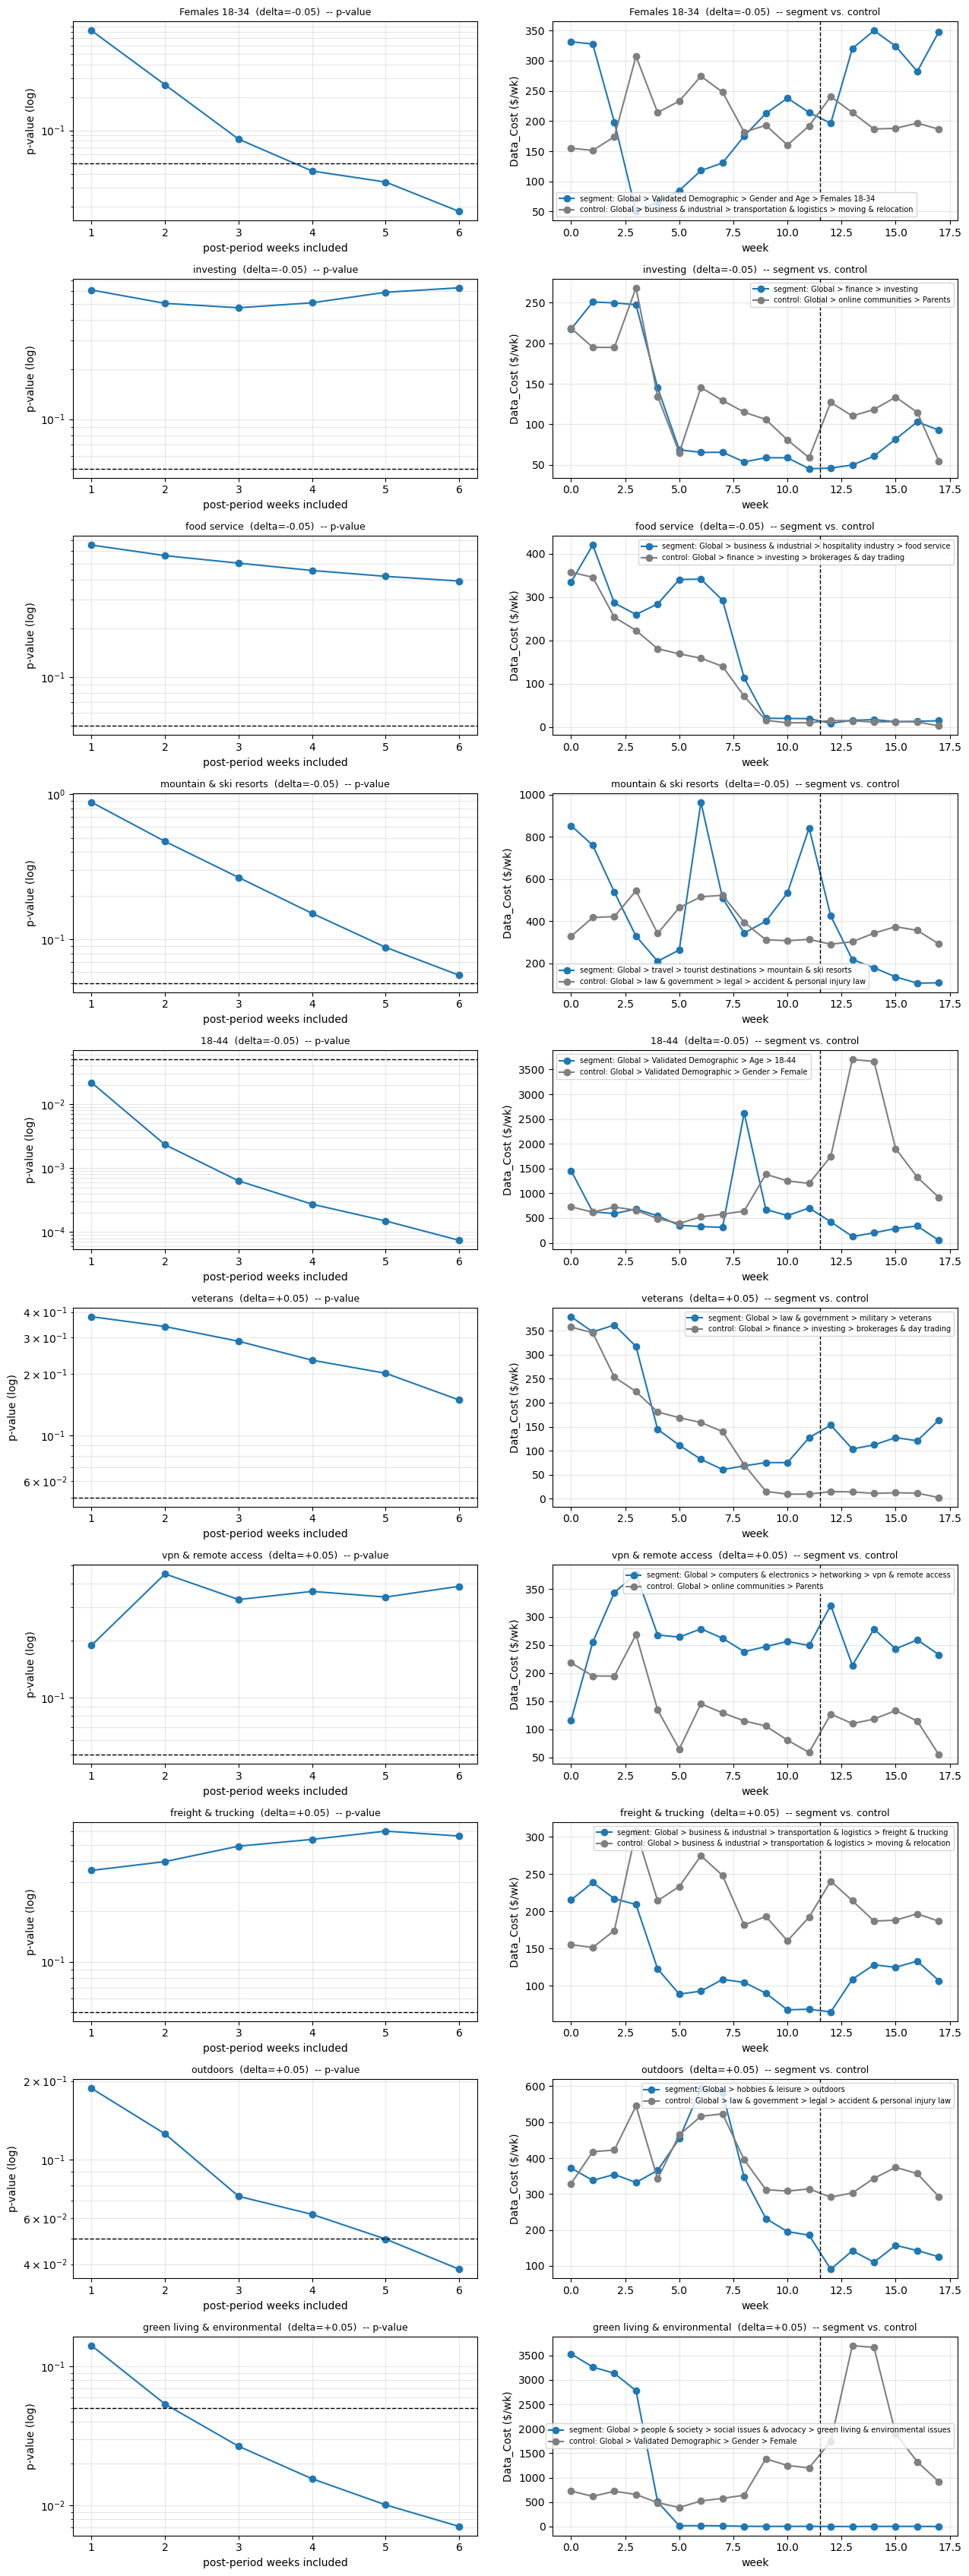

In [39]:
plot_segment_grid(result)

## Overall performance summary

A condensed, plain-English verdict per segment, plus an at-a-glance chart across all analyzed segments.

                                                                                 Full_Path  delta bucket       did  effect_size  p_value  significant_5pct                                                                 verdict
                           Global > Validated Demographic > Gender and Age > Females 18-34  -0.05  1000+   129.615        1.388    0.018              True                significant large increased (p=0.018, effect size=+1.39)
                                                              Global > finance > investing  -0.05  1000+   -22.032       -0.249    0.628             False not significant -- decreased but indistinguishable from noise (p=0.628)
                      Global > business & industrial > hospitality industry > food service  -0.05  1000+   -64.233       -0.445    0.392             False not significant -- decreased but indistinguishable from noise (p=0.392)
                           Global > travel > tourist destinations > mountain & ski resorts  

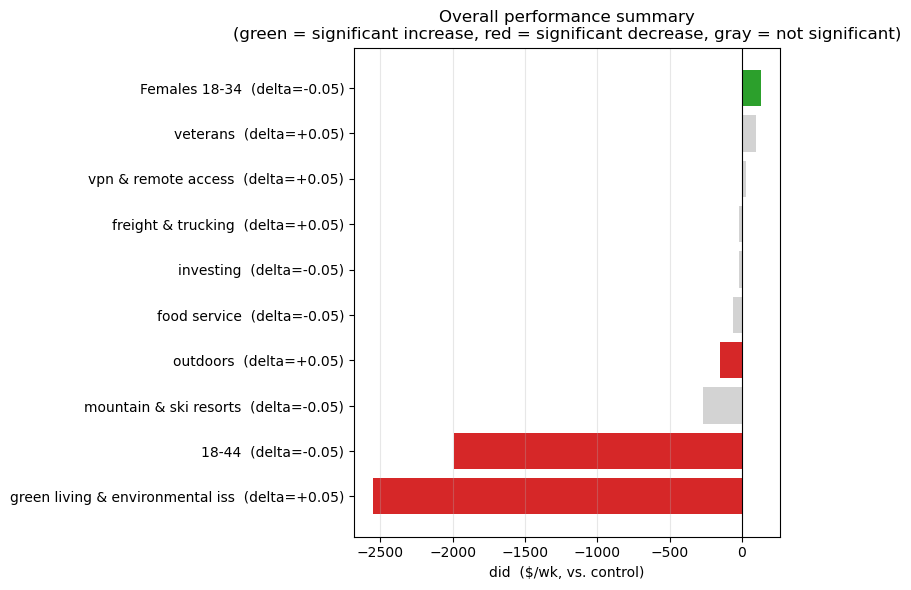

In [40]:
perf = summarize_performance(result)
pd.set_option('display.width', 200)
print(perf.round(3).to_string(index=False))
plot_performance_summary(result)